In [35]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

import shap
import joblib

In [36]:
DATA_DIR = Path("../data/processed")
ARTIFACT_DIR = Path("../model")

batsman_df = pd.read_csv(DATA_DIR / "batsman_model_data.csv", parse_dates=["date"])
pipeline = joblib.load(ARTIFACT_DIR / "feature_pipeline_batsman.pkl")

print("Dataset shape:", batsman_df.shape)

Dataset shape: (15842, 17)


In [37]:
split_date = "2023-01-01"

train_df = batsman_df[batsman_df["date"] < split_date]
test_df  = batsman_df[batsman_df["date"] >= split_date]

target = "runs_next_match"

drop_cols = ["match_id", "date", "batter", target]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (13789, 13)
Test shape: (2053, 13)


In [38]:
required_features = [
    "match_run_rate",
    "wickets_fallen",
    "wickets_left",
    "pressure_index"
]

for col in required_features:
    if col not in X_train.columns:
        raise ValueError(f"❌ Missing feature: {col}")

In [39]:
X_train_p = pipeline.transform(X_train)
X_test_p  = pipeline.transform(X_test)

feature_names = pipeline.get_feature_names_out()

In [40]:
baseline_pred = test_df["runs_avg_last_10"].fillna(
    test_df["runs_avg_last_10"].mean()
)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline Performance")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R2  :", baseline_r2)

Baseline Performance
MAE : 16.99104813706616
RMSE: 22.605654386274363
R2  : 0.041136104684815766


In [41]:
rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    min_samples_leaf=15,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_p, y_train)

rf_pred = rf.predict(X_test_p)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

Random Forest
MAE : 16.337919431715324
RMSE: 21.86329716471191
R2  : 0.10307916058808475


In [42]:
xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_p, y_train)

xgb_pred = xgb.predict(X_test_p)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2  :", xgb_r2)

XGBoost
MAE : 16.75916863068452
RMSE: 22.353081430131564
R2  : 0.06244317492022222


In [44]:
lgb = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    random_state=42
)

lgb.fit(X_train_p, y_train)

lgb_pred = lgb.predict(X_test_p)

lgb_mae = mean_absolute_error(y_test, lgb_pred)
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_pred))
lgb_r2 = r2_score(y_test, lgb_pred)

print("LightGBM")
print("MAE :", lgb_mae)
print("RMSE:", lgb_rmse)
print("R2  :", lgb_r2)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000533 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2209
[LightGBM] [Info] Number of data points in the train set: 13789, number of used features: 78
[LightGBM] [Info] Start training from score 20.045544
LightGBM
MAE : 16.684437393240216
RMSE: 22.249708331259423
R2  : 0.07109469376477517


X does not have valid feature names, but LGBMRegressor was fitted with feature names


In [47]:
param_grid = {  
    "n_estimators": [300, 400],
    "max_depth": [5, 6],
    "learning_rate": [0.03, 0.05]
}

grid = GridSearchCV(
    XGBRegressor(objective="reg:squarederror", random_state=42),
    param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_p, y_train)

best_xgb = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 300}


In [49]:
results = pd.DataFrame({
    "Model": ["Baseline", "Random Forest", "XGBoost", "LightGBM"],
    "MAE": [baseline_mae, rf_mae, xgb_mae, lgb_mae],
    "RMSE": [baseline_rmse, rf_rmse, xgb_rmse, lgb_rmse],
    "R2": [baseline_r2, rf_r2, xgb_r2, lgb_r2]
})

results.sort_values("RMSE")

,Model,MAE,RMSE,R2
1,Random Forest,16.337919,21.863297,0.103079
3,LightGBM,16.684437,22.249708,0.071095
2,XGBoost,16.759169,22.353081,0.062443
0,Baseline,16.991048,22.605654,0.041136


In [50]:
joblib.dump(rf, ARTIFACT_DIR / "rf_batsman_model.joblib")

print("✅ rf_batsman_model.joblib saved successfully")

✅ rf_batsman_model.joblib saved successfully



🧠 SHAP Feature Importance


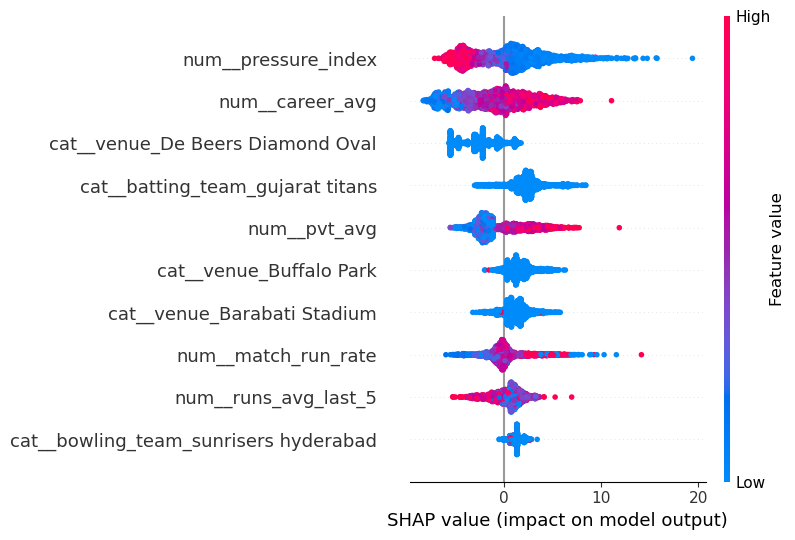

In [51]:
sample_size = min(2000, X_train_p.shape[0])

sample_idx = np.random.choice(
    X_train_p.shape[0],
    sample_size,
    replace=False
)

X_sample = X_train_p[sample_idx]

if hasattr(X_sample, "toarray"):
    X_sample = X_sample.toarray()

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_sample)

feature_names = pipeline.get_feature_names_out()

print("\n🧠 SHAP Feature Importance")

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    max_display=10
)